In [3]:
import pandas as pd
import numpy
import networkx as nx
from tqdm.notebook import tqdm
import seaborn as sns
import matplotlib.pyplot as plt


import umap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('csv/flat-training.csv')

X_train, X_test = train_test_split(df, train_size=0.8)

# X_train, X_val = train_test_split(X_tv, train_size=0.5)

original_index_values = X_train.reset_index()['index']

#df_o = df.select_dtypes(include='object')

#df_no = df.select_dtypes(exclude='object')

X_train_o = X_train.select_dtypes(include='object').fillna('iamna')

X_train_dummies = pd.get_dummies(X_train)

X_train_no = X_train.select_dtypes(exclude='object').fillna(0)

#X_val_no = X_val.select_dtypes(exclude='object').fillna(0)

# scaler_no = StandardScaler()

# X_train_no_scaled = pd.DataFrame(scaler_no.fit_transform(X_train_no))



scaler_no = MinMaxScaler()

scaler_no.fit(X_train_dummies)

X_train_scaled=pd.DataFrame(scaler_no.transform(X_train_dummies))




In [4]:
from umap.parametric_umap import ParametricUMAP

reducer_o = ParametricUMAP(parametric_reconstruction=False, verbose=True, n_components=15)

reducer_o.fit(X_train_dummies.fillna(0))

/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/umap/parametric_umap.py:148: UserWarning: tensorflow_probability not installed or incompatible to current                 tensorflow installation. Setting global_correlation_loss_weight to zero.
  warn(
/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


ParametricUMAP(optimizer=<keras.optimizers.adam.Adam object at 0x756a1380e6d0>)
Fri May 30 11:35:03 2025 Construct fuzzy simplicial set
Fri May 30 11:35:03 2025 Finding Nearest Neighbors
Fri May 30 11:35:03 2025 Building RP forest with 19 trees
Fri May 30 11:35:08 2025 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	Stopping threshold met -- exiting after 3 iterations
Fri May 30 11:35:19 2025 Finished Nearest Neighbor Search
Fri May 30 11:35:21 2025 Construct embedding


2025-05-30 11:35:47.725935: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_1' with dtype int64 and shape [101364662]
	 [[{{node Placeholder/_1}}]]
2025-05-30 11:35:47.726138: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int64 and shape [101364662]
	 [[{{node Placeholder/_0}}]]


Epoch 1/10


2025-05-30 11:35:59.110618: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]


10136/10136 [==============================] - 71s 7ms/step - loss: 0.1894
Epoch 2/10
10136/10136 [==============================] - 67s 7ms/step - loss: 0.1859
Epoch 3/10
10136/10136 [==============================] - 71s 7ms/step - loss: 0.1853
Epoch 4/10
10136/10136 [==============================] - 67s 7ms/step - loss: 0.1850
Epoch 5/10
10136/10136 [==============================] - 69s 7ms/step - loss: 0.1846
Epoch 6/10
10136/10136 [==============================] - 70s 7ms/step - loss: 0.1845
Epoch 7/10
10136/10136 [==============================] - 67s 7ms/step - loss: 0.1844
Epoch 8/10
10136/10136 [==============================] - 65s 6ms/step - loss: 0.1843
Epoch 9/10
10136/10136 [==============================] - 66s 6ms/step - loss: 0.1842
Epoch 10/10
2500/2500 [==============================] - 1s 456us/step
Fri May 30 11:47:20 2025 Finished embedding


ParametricUMAP(batch_size=1000, dims=[344], encoder=<keras.engine.sequential.Sequential object at 0x756a00ddaa50>, optimizer=<keras.optimizers.adam.Adam object at 0x756a1380e6d0>)

In [ ]:
# reducer_o = umap.UMAP(metric='cosine', n_neighbors = 100, n_components=15)

# reducer_o.fit(X_train_dummies.fillna(0))

/home/fnnsll/Hive/Honey/synthetic/.venv/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



UMAP(angular_rp_forest=True, metric='cosine', n_components=15, n_neighbors=100, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [5]:
embedding_o = pd.DataFrame(reducer_o.transform(X_train_dummies.astype('float').fillna(0)))


80/80 [==============================] - 0s 2ms/step


<Axes: xlabel='col0', ylabel='col1'>

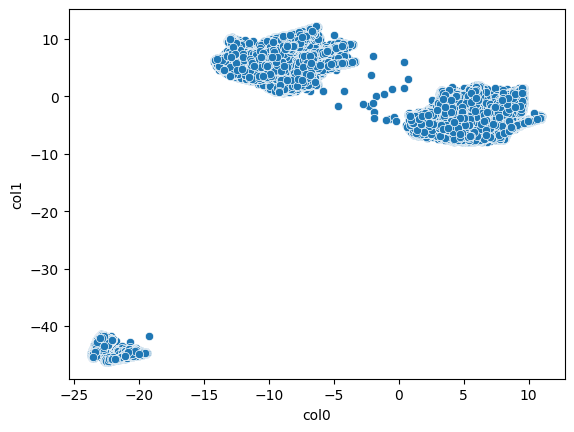

In [ ]:
#Assess how many clusters visually, map them
# embedding_o.columns = ['col0','col1']
# sns.scatterplot(embedding_o, x='col0', y='col1' )

In [6]:
import scipy.stats as stats
from sklearn import preprocessing

X_train_cat = X_train.copy()

le = preprocessing.LabelEncoder()
for i,col in enumerate(X_train_o.columns.tolist()):
    X_train_cat[col] = le.fit_transform(X_train_cat[col])

col_one = []
col_two = []
corr_list = []
for i,col_1 in enumerate(X_train.columns.tolist()):
    for j, col_2 in enumerate(X_train.columns.tolist()):
        if col_1!=col_2:
            col_one.append(col_1)
            col_two.append(col_2)
            corr_list.append(stats.pointbiserialr(X_train_cat[col_1], X_train_cat[col_2])[0])

col_dict = {
    'col1': col_one,
    'col2': col_two,
    'corr': corr_list
}

corr_df = pd.DataFrame.from_dict(col_dict)
        


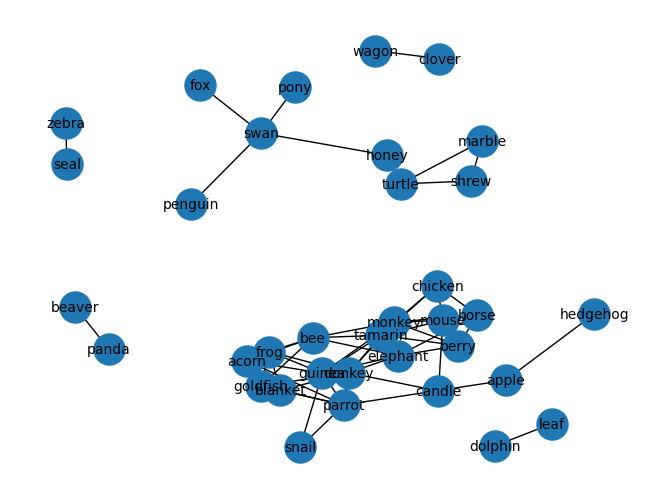

In [31]:
R = 0.5
S = 0.7
df_R = corr_df[(corr_df['corr'] > R)&(corr_df['corr']<S)]

G=nx.from_pandas_edgelist(df_R, 'col1', 'col2', edge_attr='corr')

pos = nx.spring_layout(G, k=0.5, scale=2.0)  # increase `k` or `scale` for more spacing

# Draw the graph using the custom positions
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)

plt.show()

In [8]:
sorted(nx.find_cliques(G), key=len, reverse=True)

[['acorn', 'frog', 'bee', 'goldfish'],
 ['donkey', 'blanket', 'goldfish', 'parrot'],
 ['donkey', 'blanket', 'goldfish', 'frog'],
 ['acorn', 'parrot', 'guinea'],
 ['acorn', 'parrot', 'goldfish'],
 ['acorn', 'frog', 'guinea'],
 ['donkey', 'tamarin', 'elephant'],
 ['shrew', 'marble', 'turtle'],
 ['snail', 'parrot', 'guinea'],
 ['bee', 'elephant', 'tamarin'],
 ['berry', 'horse', 'elephant'],
 ['berry', 'horse', 'monkey'],
 ['berry', 'tamarin', 'elephant'],
 ['chicken', 'horse', 'monkey'],
 ['chicken', 'mouse', 'tamarin'],
 ['chicken', 'mouse', 'monkey'],
 ['guinea', 'elephant', 'tamarin'],
 ['leaf', 'dolphin'],
 ['seal', 'zebra'],
 ['hedgehog', 'apple'],
 ['clover', 'wagon'],
 ['donkey', 'candle'],
 ['donkey', 'monkey'],
 ['pony', 'swan'],
 ['fox', 'swan'],
 ['bee', 'monkey'],
 ['mouse', 'candle'],
 ['beaver', 'panda'],
 ['guinea', 'monkey'],
 ['honey', 'swan'],
 ['swan', 'penguin'],
 ['apple', 'parrot']]

In [32]:
# Get connected components
components = list(nx.connected_components(G))

# Each component is a set of node names
component_list = []
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")
    component_list.append(list(component))

flat_list = [item for sublist in component_list for item in sublist]

singles = [x for x in X_train.columns.tolist() if x not in flat_list]

single_lists = [[x] for x in singles]
    

Component 1: {'beaver', 'panda'}
Component 2: {'elephant', 'hedgehog', 'acorn', 'tamarin', 'donkey', 'candle', 'snail', 'bee', 'berry', 'blanket', 'chicken', 'mouse', 'horse', 'guinea', 'frog', 'goldfish', 'parrot', 'apple', 'monkey'}
Component 3: {'leaf', 'dolphin'}
Component 4: {'honey', 'swan', 'fox', 'penguin', 'pony'}
Component 5: {'marble', 'turtle', 'shrew'}
Component 6: {'seal', 'zebra'}
Component 7: {'clover', 'wagon'}


In [33]:
X_train_singles_cat = X_train[singles]
object_columns = X_train_singles_cat.select_dtypes(include='object').columns.tolist()

le = preprocessing.LabelEncoder()
for i,col in enumerate(object_columns):
    X_train_singles_cat[col] = le.fit_transform(X_train_singles_cat[col])

col_one = []
col_two = []
corr_list = []
for i,col_1 in enumerate(X_train_singles_cat.columns.tolist()):
    for j, col_2 in enumerate(X_train_singles_cat.columns.tolist()):
        if col_1!=col_2:
            col_one.append(col_1)
            col_two.append(col_2)
            corr_list.append(stats.pointbiserialr(X_train_singles_cat[col_1], X_train_singles_cat[col_2])[0])

col_dict = {
    'col1': col_one,
    'col2': col_two,
    'corr': corr_list
}

corr_df_singles = pd.DataFrame.from_dict(col_dict)

/tmp/ipykernel_250391/2931359101.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_singles_cat[col] = le.fit_transform(X_train_singles_cat[col])
/tmp/ipykernel_250391/2931359101.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_singles_cat[col] = le.fit_transform(X_train_singles_cat[col])
/tmp/ipykernel_250391/2931359101.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

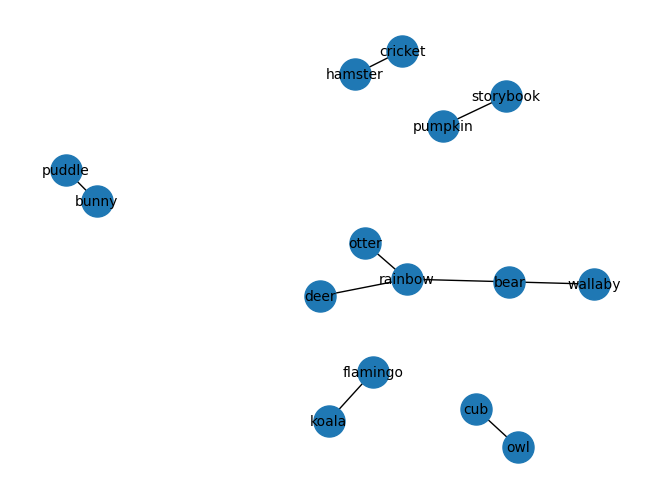

In [34]:
R = 0.2
S = 0.4
df_R = corr_df_singles[(corr_df_singles['corr'] > R)&(corr_df_singles['corr']<S)]

G=nx.from_pandas_edgelist(df_R, 'col1', 'col2', edge_attr='corr')

pos = nx.spring_layout(G, k=0.5, scale=2.0)  # increase `k` or `scale` for more spacing

# Draw the graph using the custom positions
nx.draw(G, pos, with_labels=True, node_size=500, font_size=10)

plt.show()

In [46]:
# Get connected components
components = list(nx.connected_components(G))

# Each component is a set of node names
component_list_two = []
for i, component in enumerate(components):
    print(f"Component {i+1}: {component}")
    component_list_two.append(list(component))

flat_list_two = [item for sublist in component_list_two for item in sublist]

singles = [x for x in X_train_singles_cat.columns.tolist() if x not in flat_list_two]

single_lists = [[x] for x in singles]

Component 1: {'wallaby', 'rainbow', 'deer', 'otter', 'bear'}
Component 2: {'flamingo', 'koala'}
Component 3: {'cricket', 'hamster'}
Component 4: {'cub', 'owl'}
Component 5: {'bunny', 'puddle'}
Component 6: {'pumpkin', 'storybook'}


In [47]:
len(component_list+component_list_two+single_lists)

43

In [49]:
pd.Series([item for sublist in component_list_two+component_list+single_lists for item in sublist]).value_counts().value_counts()

count
1    80
Name: count, dtype: int64

In [58]:
def random_sample_o_column_proportions(df, col):
    return df[col].sample(50000, replace=True).reset_index(drop='True')

o_col_list = component_list+component_list_two+single_lists
random_dataframe_from_col_space = pd.DataFrame()
for i, col in enumerate(o_col_list):
    random_dataframe_from_col_space = pd.concat([random_dataframe_from_col_space,
               random_sample_o_column_proportions(X_train, col)], axis=1)
    
random_dataframe_from_col_space = random_dataframe_from_col_space[X_train.columns.tolist()]
    
expanded_random = pd.get_dummies(random_dataframe_from_col_space)

X_train_o_fake_sample = reducer_o.transform(expanded_random.astype('float').fillna(0))
X_train_o_fake_sample = pd.DataFrame(X_train_o_fake_sample)

50/50 [==============================] - 0s 2ms/step


In [56]:
random_dataframe_from_col_space.head()

,dog,cat,rabbit,deer,panda,koala,otter,hedgehog,squirrel,dolphin,...,blanket,button,whistle,marble,wagon,storybook,candle,clover,bubble,cookie
0,51,027A,NaN,2.75,0,T3,027A,41.0,1,1,...,A1,25,1,1,-1.04,59,B0,0.06,0,C18
1,11,D668,NaN,4.31,-4,T1,027A,75.0,0,1,...,A9,-14,7,0,-0.90,-72,B0,0.27,1,C2
2,86,C9CF,NaN,1.37,-2,T1,027A,29.0,1,1,...,A2,14,-2,0,-0.55,67,B2,0.52,0,C11
3,54,B9DE,20.0,2.38,-1,T3,027A,36.2,1,1,...,A1,7,10,0,-0.96,-73,B0,0.20,0,C0
4,86,A2FB,NaN,4.11,-1,T3,027A,41.0,1,1,...,A5,25,10,0,-0.68,51,B2,2.11,0,C3


In [ ]:

# X_train_o_fake_sample.columns = ['col0','col1']

# sns.scatterplot(X_train_o_fake_sample, x='col0', y='col1' )

In [ ]:
def euclidean_metric(df):
    return numpy.sqrt(numpy.sum(df**2, axis=1))

distance = []
for i in tqdm(range(X_train_o_fake_sample.shape[0]), total=X_train_o_fake_sample.shape[0]):
    distance.append((euclidean_metric(embedding_o - X_train_o_fake_sample.iloc[i]) < 0.15).sum())

distance = pd.Series(distance)

X_test_fake_o = random_dataframe_from_col_space.iloc[distance[distance > 0].reset_index()['index']]#.sample(X_test.shape[0])

#X_test_fake_o.replace('iamna', numpy.nan, inplace=True)

print((distance > 0).sum(), (distance > 0).sum()/len(distance))

  0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
(distance > 0).sum(), (distance > 0).sum()/len(distance)

(553, 0.553)

In [230]:
X_test_fake_o = random_dataframe_from_col_space.iloc[distance[distance > 3].reset_index()['index']]

In [231]:
from mostlyai import qa
qa.init_logging()

report_path, metrics = qa.report(syn_tgt_data=X_test_fake_o,
                                 trn_tgt_data=X_train,
                                 hol_tgt_data=X_test)

print(metrics.model_dump_json(indent=4))

[2025-05-30 10:58:57,377] INFO   : prepared training data for accuracy: (80000, 80)
[2025-05-30 10:58:57,632] INFO   : prepared holdout data for accuracy: (20000, 80)
[2025-05-30 10:58:58,127] INFO   : prepared synthetic data for accuracy: (50000, 80)
[2025-05-30 10:58:58,280] INFO   : encode datasets for embeddings
[2025-05-30 10:59:03,397] INFO   : calculated embeddings: syn=(20000, 107), trn=(20000, 107), hol=(20000, 107)
[2025-05-30 10:59:03,397] INFO   : report accuracy and correlations
[2025-05-30 10:59:03,398] INFO   : calculate original data bins
[2025-05-30 10:59:04,169] INFO   : store original data bins
[2025-05-30 10:59:04,288] INFO   : calculate synthetic data bins
[2025-05-30 10:59:04,536] INFO   : calculate correlations
[2025-05-30 10:59:11,911] INFO   : calculate correlations
[2025-05-30 10:59:17,218] INFO   : calculated univariates for 80 columns in 1.34 seconds
[2025-05-30 10:59:24,529] INFO   : calculated bivariate accuracies for 6320 combinations in 7.31 seconds
[202

In [203]:
random_dataframe_from_col_space.to_csv('submission_1.csv')